# Regression — leakage-safe preprocessing, error analysis and stability


## Goal
Exercise regression with missing values, fold-local imputation/scaling, a broad metric panel, OOF residual diagnostics, fold stability and worst-sample reporting.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("MLCORE_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from sklearn.datasets import make_regression
from mlcore import validate
from mlcore.datasets import DatasetBundle, PartitionPlan


In [2]:
rng=np.random.default_rng(55)
n_samples=150 if DEMO_TEST else 360
X,y=make_regression(n_samples=n_samples,n_features=16,n_informative=10,noise=18.0,random_state=55)
# Introduce missingness only in X; fold-local imputation must handle it.
mask=rng.random(X.shape)<0.025
X[mask]=np.nan
ids=[f"reg_{i:04d}" for i in range(len(y))]
dataset=DatasetBundle(X=X,y=y,sample_ids=ids,feature_names=[f"f{i:02d}" for i in range(X.shape[1])])
plan=PartitionPlan.from_predefined_folds(sample_ids=ids,fold_assignments=np.arange(len(y))%5,
                                         dataset_fingerprint=dataset.fingerprint)


In [3]:
metrics=("rmse","mae","median_ae","r2","explained_variance","pearson","spearman")
result=validate(dataset=dataset,algorithm="ridge_regressor",partition_plan=plan,metrics=metrics,random_state=42)
oof=result.oof_prediction
assert oof is not None
report=pd.DataFrame({"sample_id":ids,"y_true":y,"y_pred":oof.predictions})
report["residual"]=report.y_true-report.y_pred
report["absolute_error"]=report.residual.abs()
report["target_quartile"]=pd.qcut(report.y_true,4,labels=["Q1","Q2","Q3","Q4"])
quartile_error=report.groupby("target_quartile",observed=True)["absolute_error"].agg(["mean","median","max"])
worst=report.nlargest(10,"absolute_error")
fold_metrics=pd.DataFrame([{"fold":f.split_name,**f.evaluation.metrics} for f in result.folds])
print(pd.Series(result.aggregate_metrics).round(4)); quartile_error


explained_variance     0.9708
mae                   21.3693
median_ae             14.5460
pearson                0.9853
r2                     0.9706
rmse                  33.7246
spearman               0.9822
dtype: float64


,mean,median,max
target_quartile,,,
Q1,22.788102,15.610853,208.216039
Q2,23.242524,15.236356,213.247107
Q3,15.896653,12.604639,107.023311
Q4,23.549752,16.731558,155.085144


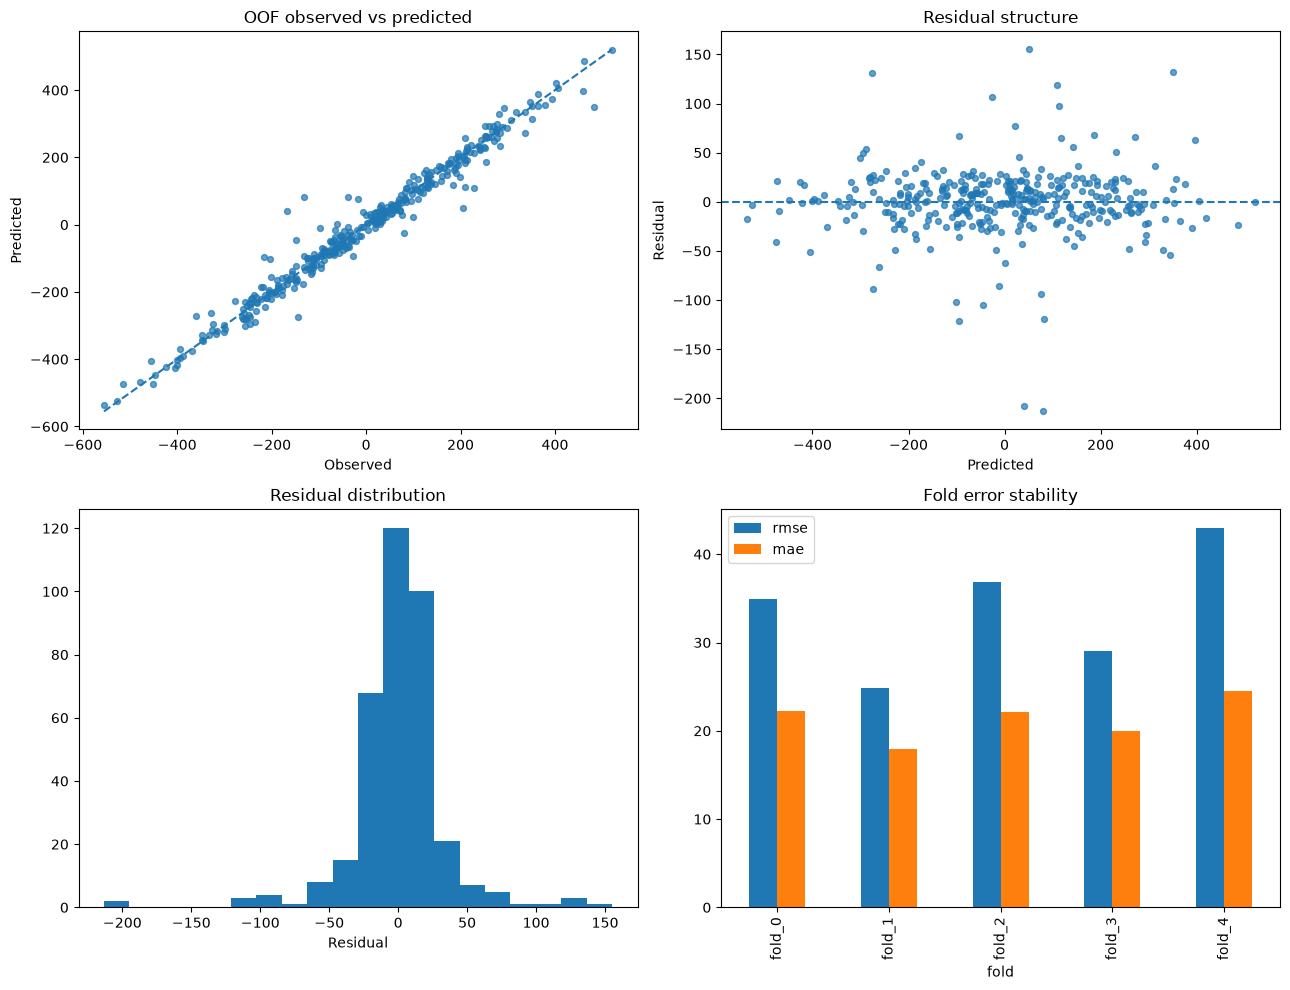

In [4]:
fig,axes=plt.subplots(2,2,figsize=(13,10))
axes[0,0].scatter(report.y_true,report.y_pred,s=18,alpha=.7); lo=min(y.min(),oof.predictions.min()); hi=max(y.max(),oof.predictions.max()); axes[0,0].plot([lo,hi],[lo,hi],"--"); axes[0,0].set(title="OOF observed vs predicted",xlabel="Observed",ylabel="Predicted")
axes[0,1].scatter(report.y_pred,report.residual,s=18,alpha=.7); axes[0,1].axhline(0,linestyle="--"); axes[0,1].set(title="Residual structure",xlabel="Predicted",ylabel="Residual")
axes[1,0].hist(report.residual,bins=20); axes[1,0].set(title="Residual distribution",xlabel="Residual")
fold_metrics.set_index("fold")[["rmse","mae"]].plot.bar(ax=axes[1,1]); axes[1,1].set_title("Fold error stability")
plt.tight_layout(); FIGURE_COUNT=1


In [5]:
DEMO_CHECKS={
    "complete_oof": result.metadata["oof_complete"] is True,
    "all_metrics": set(metrics)==set(result.aggregate_metrics),
    "missing_values_exercised": np.isnan(dataset.X).any(),
    "quartile_report": len(quartile_error)==4,
    "worst_samples_traceable": worst.sample_id.is_unique,
    "finite_metrics": all(np.isfinite(v) for v in result.aggregate_metrics.values()),
    "figure_created": FIGURE_COUNT==1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'complete_oof': True,
 'all_metrics': True,
 'missing_values_exercised': np.True_,
 'quartile_report': True,
 'worst_samples_traceable': True,
 'finite_metrics': True,
 'figure_created': True}